In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

Number of unique pairs: 190

Strongest pair: var_13 & var_18
  r = 0.168
  p = 0.01123

Pairs with p < 0.05 ('significant') by chance: 7 of 190 


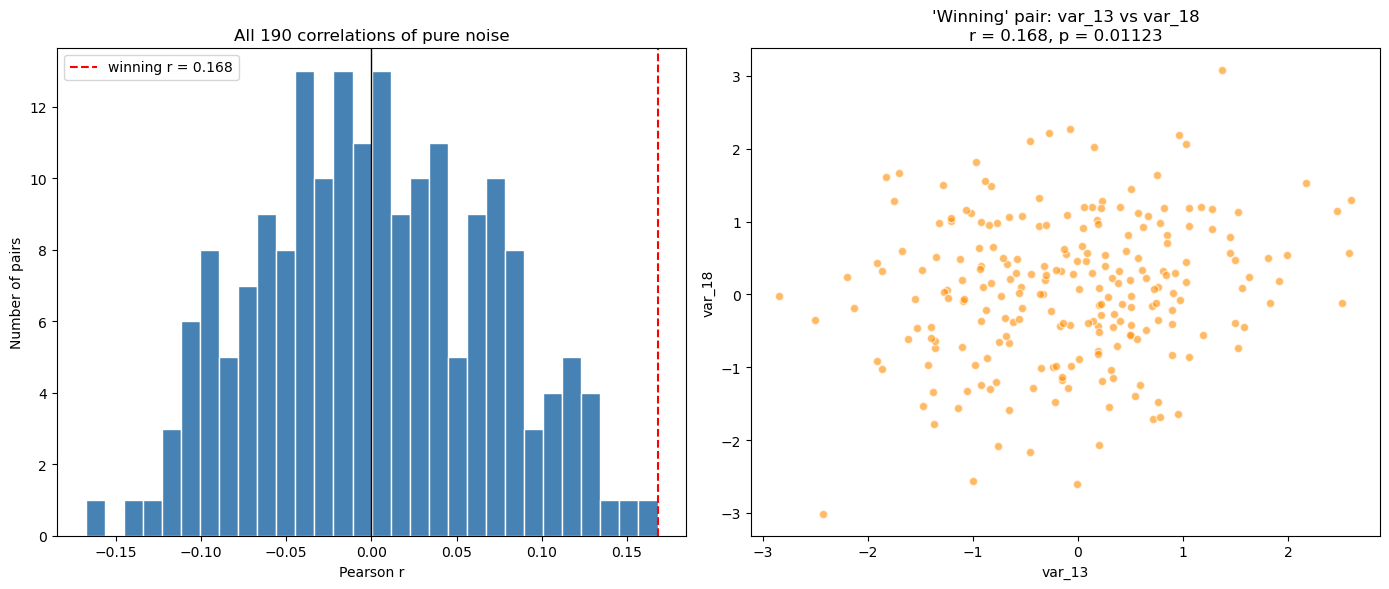

In [6]:
from itertools import combinations

# 1. Fixed seed + 20 columns of pure noise, 227 rows each
np.random.seed(42)
n_rows, n_cols = 227, 20
noise = pd.DataFrame(
    np.random.standard_normal((n_rows, n_cols)),
    columns=[f"var_{i}" for i in range(n_cols)],
)

# 2. Pearson r (and p) for all unique column pairs
results = []  # (col_a, col_b, r, p)
for a, b in combinations(noise.columns, 2):
    r, p = stats.pearsonr(noise[a], noise[b])
    results.append((a, b, r, p))

r_values = [r for _, _, r, _ in results]
print(f"Number of unique pairs: {len(results)}")

# 3. Strongest correlation by absolute r
best = max(results, key=lambda x: abs(x[2]))
ba, bb, br, bp = best
print(f"\nStrongest pair: {ba} & {bb}")
print(f"  r = {br:.3f}")
print(f"  p = {bp:.4g}")

# 4. How many reached p < 0.05 purely by chance
n_sig = sum(1 for *_, p in results if p < 0.05)
print(f"\nPairs with p < 0.05 ('significant') by chance: {n_sig} of {len(results)}"
      f" ")

# 5a. Histogram of all correlations  5b. Scatter of the winning pair
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].hist(r_values, bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="black", linewidth=1)
axes[0].axvline(br, color="red", linestyle="--", label=f"winning r = {br:.3f}")
axes[0].set_title("All 190 correlations of pure noise")
axes[0].set_xlabel("Pearson r")
axes[0].set_ylabel("Number of pairs")
axes[0].legend()

axes[1].scatter(noise[ba], noise[bb], alpha=0.6, color="darkorange", edgecolor="white")
axes[1].set_title(f"'Winning' pair: {ba} vs {bb}\nr = {br:.3f}, p = {bp:.4g}")
axes[1].set_xlabel(ba)
axes[1].set_ylabel(bb)

plt.tight_layout()
plt.show()